In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import metrics
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
data = pd.read_csv("X_full_scaled.csv")


In [3]:
print("Dataset shape:", data.shape)
print(data.head())

Dataset shape: (7043, 9)
   gender  SeniorCitizen  Dependents    tenure  PhoneService  MultipleLines  \
0       1              0           1  0.013889             1              0   
1       0              0           0  0.416667             1              0   
2       0              1           0  0.638889             1              1   
3       1              0           0  0.597222             1              0   
4       1              0           0  0.013889             1              1   

   InternetService  Contract  MonthlyCharges  
0                0         2        0.415842  
1                0         1        0.366337  
2                1         0        0.811881  
3                0         1        0.475248  
4                1         2        0.019802  


In [4]:
# elbow method
sse = []
silhouette_scores = []

k_range = range(1, 11)

for k in k_range:
    #kmeans = KMeans(n_clusters = k, random_state=42, n_init=10)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(data)
    sse.append(kmeans.inertia_)

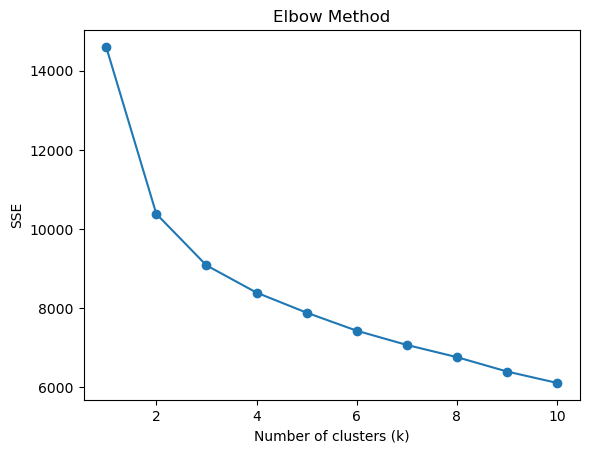

In [5]:
# Plot Elbow Method

plt.plot(k_range, sse, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("SSE")
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


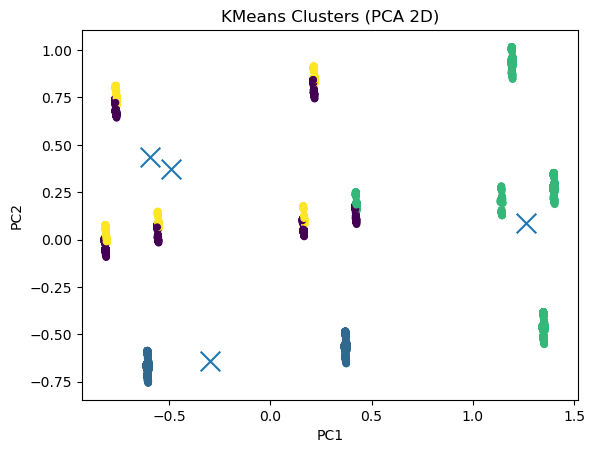

In [26]:
# according to the elbow plot, k = 4 is selected as the optimal number of clusters ...
# KMeans clustering
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(data)
# PCA for 2D visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(data)
centers_pca = pca.transform(kmeans.cluster_centers_)
# Plot
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=20)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], marker="x", s=200)
plt.title("KMeans Clusters (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [27]:
# Original Cleaned data
data_original = pd.read_csv("Dataset_ATS_v2.csv")

data_original["gender"] = data_original["gender"].map({"Female": 0, "Male": 1})
data_original["Dependents"] = data_original["Dependents"].map({"No": 0, "Yes": 1})
data_original["PhoneService"] = data_original["PhoneService"].map({"No": 0, "Yes": 1})
data_original["MultipleLines"] = data_original["MultipleLines"].map({"No": 0, "Yes": 1})
data_original["InternetService"] = data_original["InternetService"].map({"DSL": 0, "Fiber optic": 1})
data_original["Churn"] = data_original["Churn"].map({"No": 0, "Yes": 1})

contract_map = {
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
}
data_original["Contract"] = data_original["Contract"].map(contract_map)

data_original["Cluster"] = labels


In [28]:
data_original.groupby("Cluster")[["tenure", "MonthlyCharges"]].mean()


,tenure,MonthlyCharges
Cluster,,
0,33.008453,65.051365
1,31.938710,65.590783
2,32.368189,64.166208
3,32.347167,63.982213


In [29]:
pd.crosstab(data_original["Cluster"], data_original["Contract"], normalize="index")


Contract,0,1,2
Cluster,,,
0,0.563719,0.212614,0.223667
1,0.551613,0.207373,0.241014
2,0.548156,0.209136,0.242708
3,0.536891,0.208169,0.254941


In [30]:
data_original.groupby("Cluster")["Churn"].mean()


Cluster
0    0.245774
1    0.281567
2    0.260870
3    0.267457
Name: Churn, dtype: float64

In [31]:
data_original.groupby("Cluster").mean()

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn
Cluster,,,,,,,,,,
0,0.487646,0.163849,0.304941,33.008453,0.904421,0.426528,0.433680,0.659948,65.051365,0.245774
1,0.516129,0.173733,0.291244,31.938710,0.904147,0.421659,0.446544,0.689401,65.590783,0.281567
2,0.506329,0.156302,0.290589,32.368189,0.902036,0.414970,0.443588,0.694551,64.166208,0.260870
3,0.503953,0.150856,0.316864,32.347167,0.901845,0.425560,0.430830,0.718050,63.982213,0.267457
